In [274]:
import random
import os

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
from PIL import Image

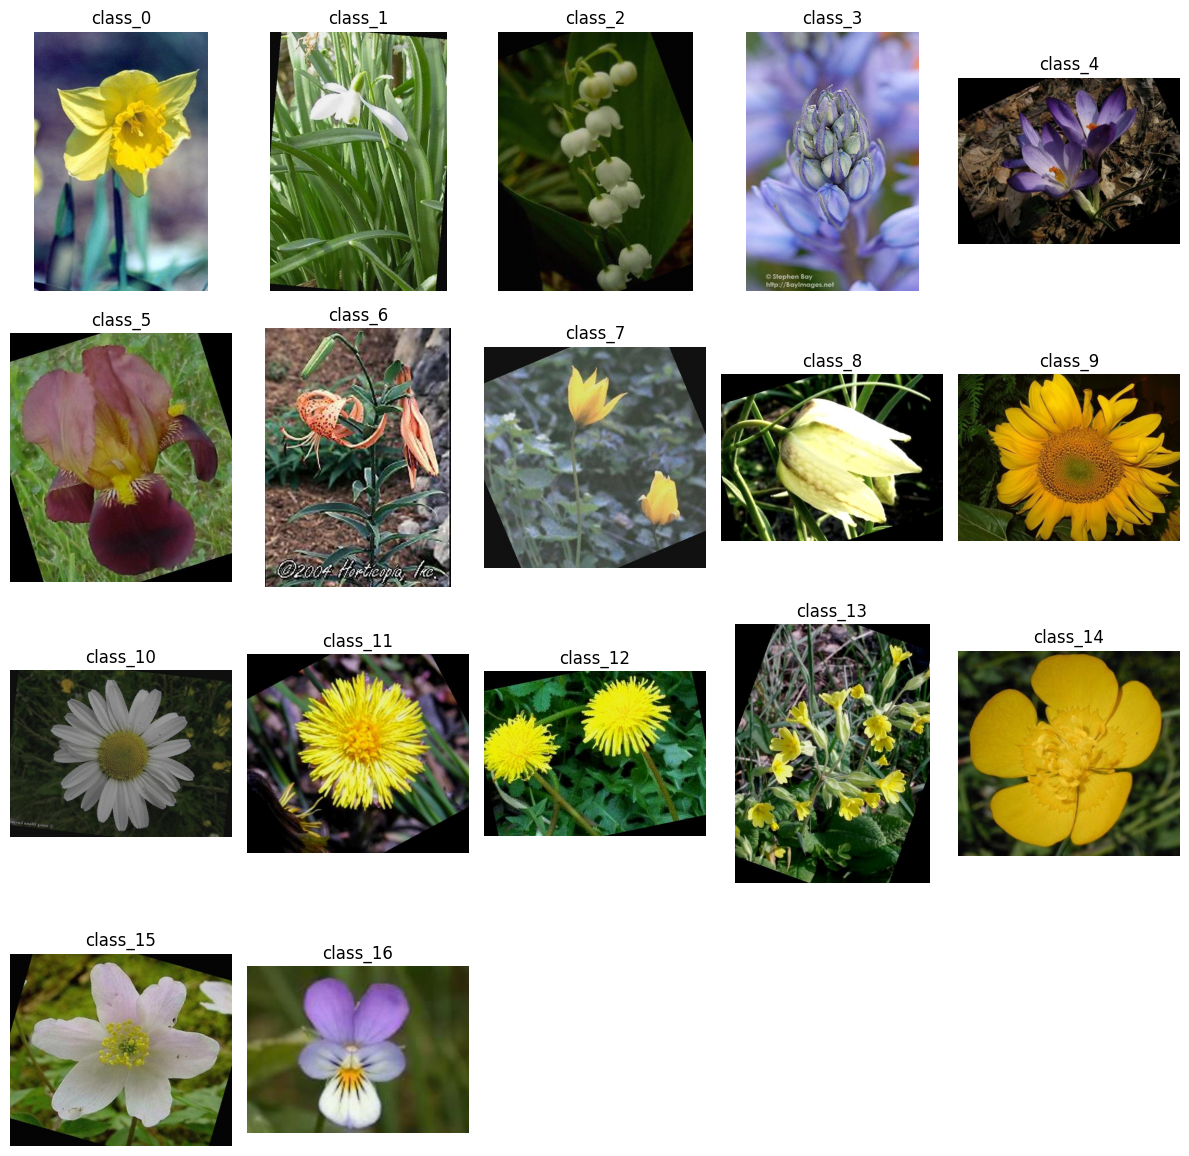

In [275]:
# data_dir = 'sorted_dataset'
data_dir = 'augmented_dataset'

class_dirs = os.listdir(data_dir)
class_dirs= sorted(class_dirs, key=lambda x: int(x.split('_')[1]))

plt.figure(figsize=(12, 12))

for i, class_dir in enumerate(class_dirs):
    class_path = os.path.join(data_dir, class_dir)
    
    class_images = os.listdir(class_path)
    
    img_path = os.path.join(class_path, class_images[0])
    image = Image.open(img_path)
    
    plt.subplot(4, 5, i + 1)
    plt.imshow(image)
    plt.title(class_dir)
    plt.axis('off')

plt.tight_layout()
plt.show()


In [276]:

# data_dir = "sorted_dataset"

batch_size = 32
epochs = 10
learning_rate = 0.00005
val_split = 0.15
test_split = 0.15
image_size = 224
torch.set_default_dtype(torch.float32)

In [277]:
train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    # transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomGrayscale(p=0.1),
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)),
])

test_val_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [278]:
dataset = datasets.ImageFolder(root=data_dir)  
num_classes = len(dataset.classes)

train_size = int((1 - val_split - test_split) * len(dataset))
val_size = int(val_split * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])


In [279]:
train_dataset.dataset = datasets.ImageFolder(root=data_dir, transform=train_transform)
val_dataset.dataset = datasets.ImageFolder(root=data_dir, transform=test_val_transform)
test_dataset.dataset = datasets.ImageFolder(root=data_dir, transform=test_val_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [280]:
model = models.resnet18(pretrained=True)

#   заморозка всех слоев резнетки
for param in model.parameters():
    param.requires_grad = False  

#   количесвто признаков, которые принимает полносвязный слой (512)
in_features = model.fc.in_features

#   замена последнего слоя (откидываем 30% признаков, выходное количество классов = 17)
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, num_classes)
)

#   разморозка fc соря
for param in model.fc.parameters():
    param.requires_grad = True  

model = model.to(torch.device("mps"))


/Users/xd/Desktop/nsu_2course/2_sem/AI/venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/xd/Desktop/nsu_2course/2_sem/AI/venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [281]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)

In [282]:
for images, labels in train_loader:
    print(f"Image dtype: {images.dtype}, Label dtype: {labels.dtype}")
    break


Image dtype: torch.float32, Label dtype: torch.int64


In [ ]:
def evaluate(model, loader, criterion, device, isTest):
    class_names = dataset.classes 
    device = torch.device("mps")
    model.eval()
    correct, total = 0, 0
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device).float(), labels.to(device).long()
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy()) 
    
    acc = 100.0 * correct / total
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')

    
    if isTest:
        class_indices = [i for i in range(len(class_names))]
        cm = confusion_matrix(all_labels, all_preds, labels=class_indices)
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        plt.title("Confusion Matrix")
        plt.show()
    return acc, total_loss, precision, recall, f1

In [284]:
for images, labels in train_loader:
    print(f"Image dtype: {images.dtype}, Label dtype: {labels.dtype}")
    break


Image dtype: torch.float32, Label dtype: torch.int64


In [ ]:
train_accuracy_arr = []
val_accuracy_arr = []
train_loss_arr = []
val_loss_arr = []
val_precisson_arr = []
val_recall_arr = []
val_f1_arr = []

def train(model, train_loader, val_loader, criterion, optimizer, epochs):
    device = torch.device("mps")
    model.to(device)
    model.train()
    
    for epoch in range(epochs):
        running_loss = 0.0
        correct, total = 0, 0
        
        for images, labels in train_loader:
            images, labels = images.to(device).float(), labels.to(device).long()
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        train_acc = 100.0 * correct / total
        val_acc, val_loss, val_precission, val_recall, val_f1 = evaluate(model, val_loader, criterion, device, 0)

        train_accuracy_arr.append(train_acc)
        val_accuracy_arr.append(val_acc)
        train_loss_arr.append(running_loss/len(train_loader))
        val_loss_arr.append(val_loss/len(train_loader))
        val_precisson_arr.append(val_precission)
        val_recall_arr.append(val_recall)
        val_f1_arr.append(val_f1)
        
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {running_loss/len(train_loader):.4f},  Val Loss: {val_loss/len(train_loader):.4f}, Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%, Precisson: {val_precission:.2f}, Recall: {val_recall:.2f}, F1: {val_f1:.2f}")


In [287]:
for param in model.parameters():
    param.requires_grad = True

train(model, train_loader, val_loader, criterion, optimizer, epochs)

Epoch 1/10, Train Loss: 1.3208,  Val Loss: 0.0563, Train Acc: 66.22%, Val Acc: 94.85%, Precisson: 0.95, Recall: 0.95, F1: 0.95
Epoch 2/10, Train Loss: 0.2282,  Val Loss: 0.0198, Train Acc: 92.93%, Val Acc: 97.06%, Precisson: 0.97, Recall: 0.97, F1: 0.97
Epoch 3/10, Train Loss: 0.1238,  Val Loss: 0.0166, Train Acc: 95.74%, Val Acc: 97.06%, Precisson: 0.98, Recall: 0.97, F1: 0.97
Epoch 4/10, Train Loss: 0.0804,  Val Loss: 0.0029, Train Acc: 97.22%, Val Acc: 99.88%, Precisson: 1.00, Recall: 1.00, F1: 1.00
Epoch 5/10, Train Loss: 0.0860,  Val Loss: 0.0051, Train Acc: 97.37%, Val Acc: 99.02%, Precisson: 0.99, Recall: 0.99, F1: 0.99
Epoch 6/10, Train Loss: 0.0605,  Val Loss: 0.0071, Train Acc: 98.24%, Val Acc: 99.02%, Precisson: 0.99, Recall: 0.99, F1: 0.99
Epoch 7/10, Train Loss: 0.0747,  Val Loss: 0.0020, Train Acc: 97.53%, Val Acc: 99.75%, Precisson: 1.00, Recall: 1.00, F1: 1.00
Epoch 8/10, Train Loss: 0.0379,  Val Loss: 0.0078, Train Acc: 98.82%, Val Acc: 98.90%, Precisson: 0.99, Recall:

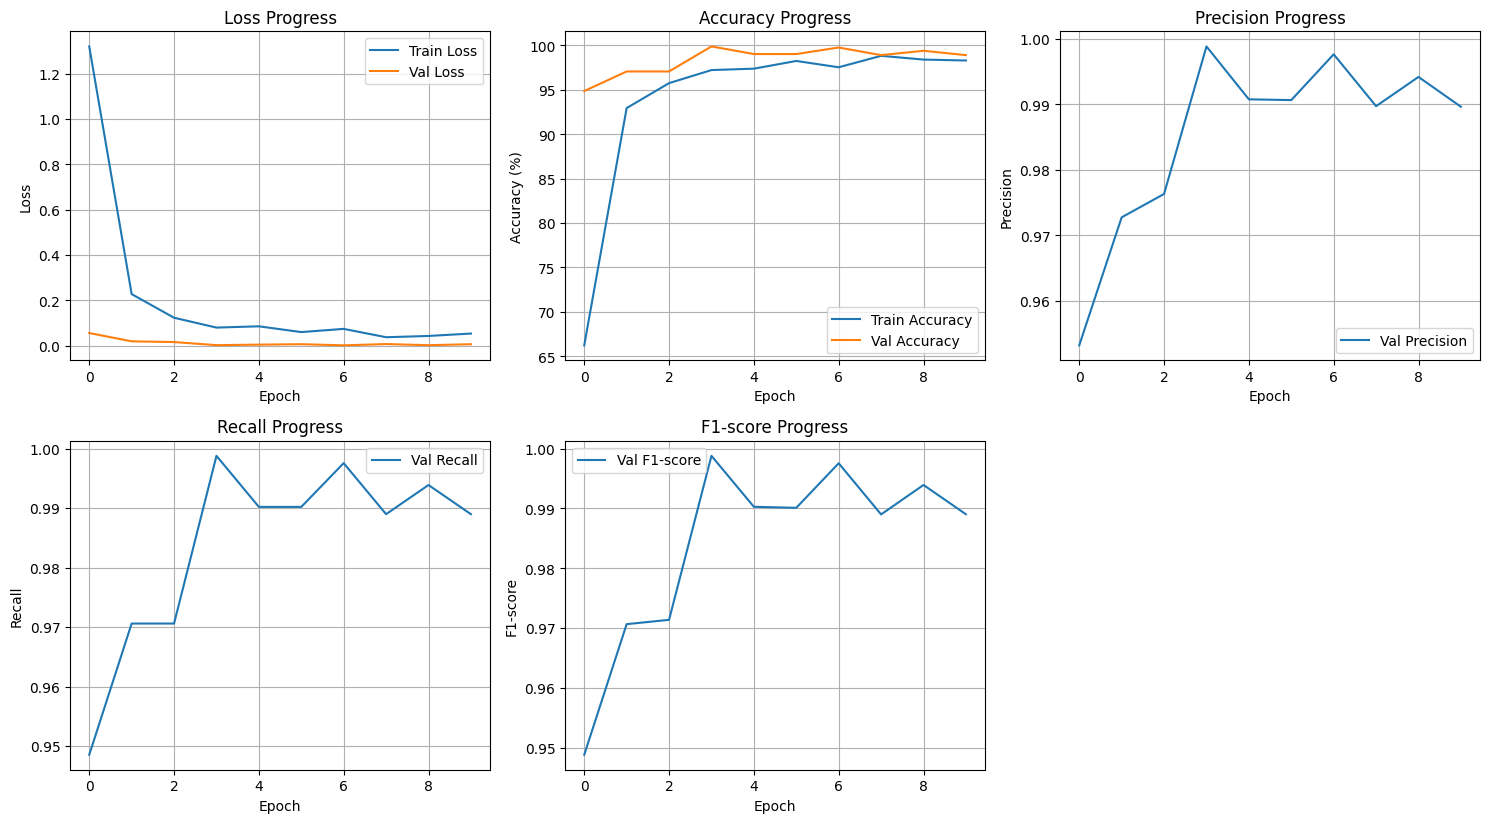

In [ ]:
plt.figure(figsize=(15, 12))


plt.subplot(3, 3, 1)
plt.plot(train_loss_arr, label='Train Loss')
plt.plot(val_loss_arr, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.title('Loss Progress')


plt.subplot(3, 3, 2)
plt.plot(train_accuracy_arr, label='Train Accuracy')
plt.plot(val_accuracy_arr, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.title('Accuracy Progress')


plt.subplot(3, 3, 3)
plt.plot(val_precisson_arr, label='Val Precision')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)
plt.title('Precision Progress')


plt.subplot(3, 3, 4)
plt.plot(val_recall_arr, label='Val Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)
plt.title('Recall Progress')


plt.subplot(3, 3, 5)
plt.plot(val_f1_arr, label='Val F1-score')
plt.xlabel('Epoch')
plt.ylabel('F1-score')
plt.legend()
plt.grid(True)
plt.title('F1-score Progress')

# Плотное размещение графиков
plt.tight_layout()
plt.show()


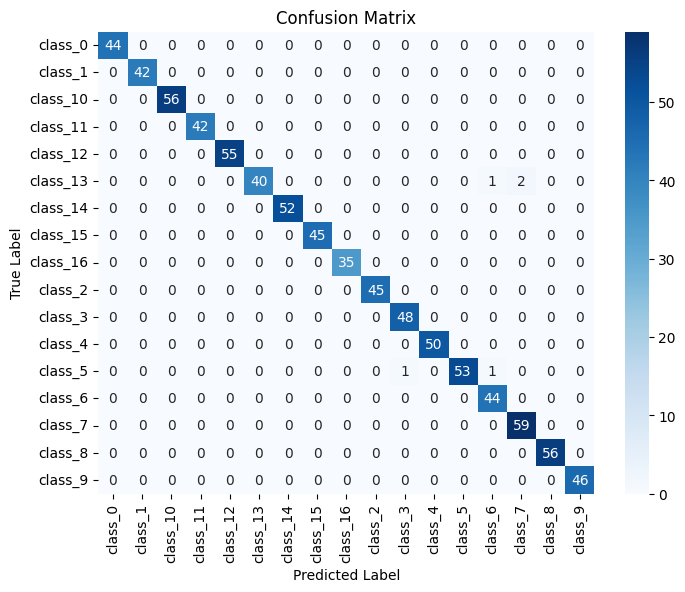

Test Accuracy: 99.39%


In [289]:
isTrain = 1
dev = torch.device("mps")
test_acc, _, _, _, _ = evaluate(model, test_loader, criterion, dev, isTrain)
print(f"Test Accuracy: {test_acc:.2f}%")

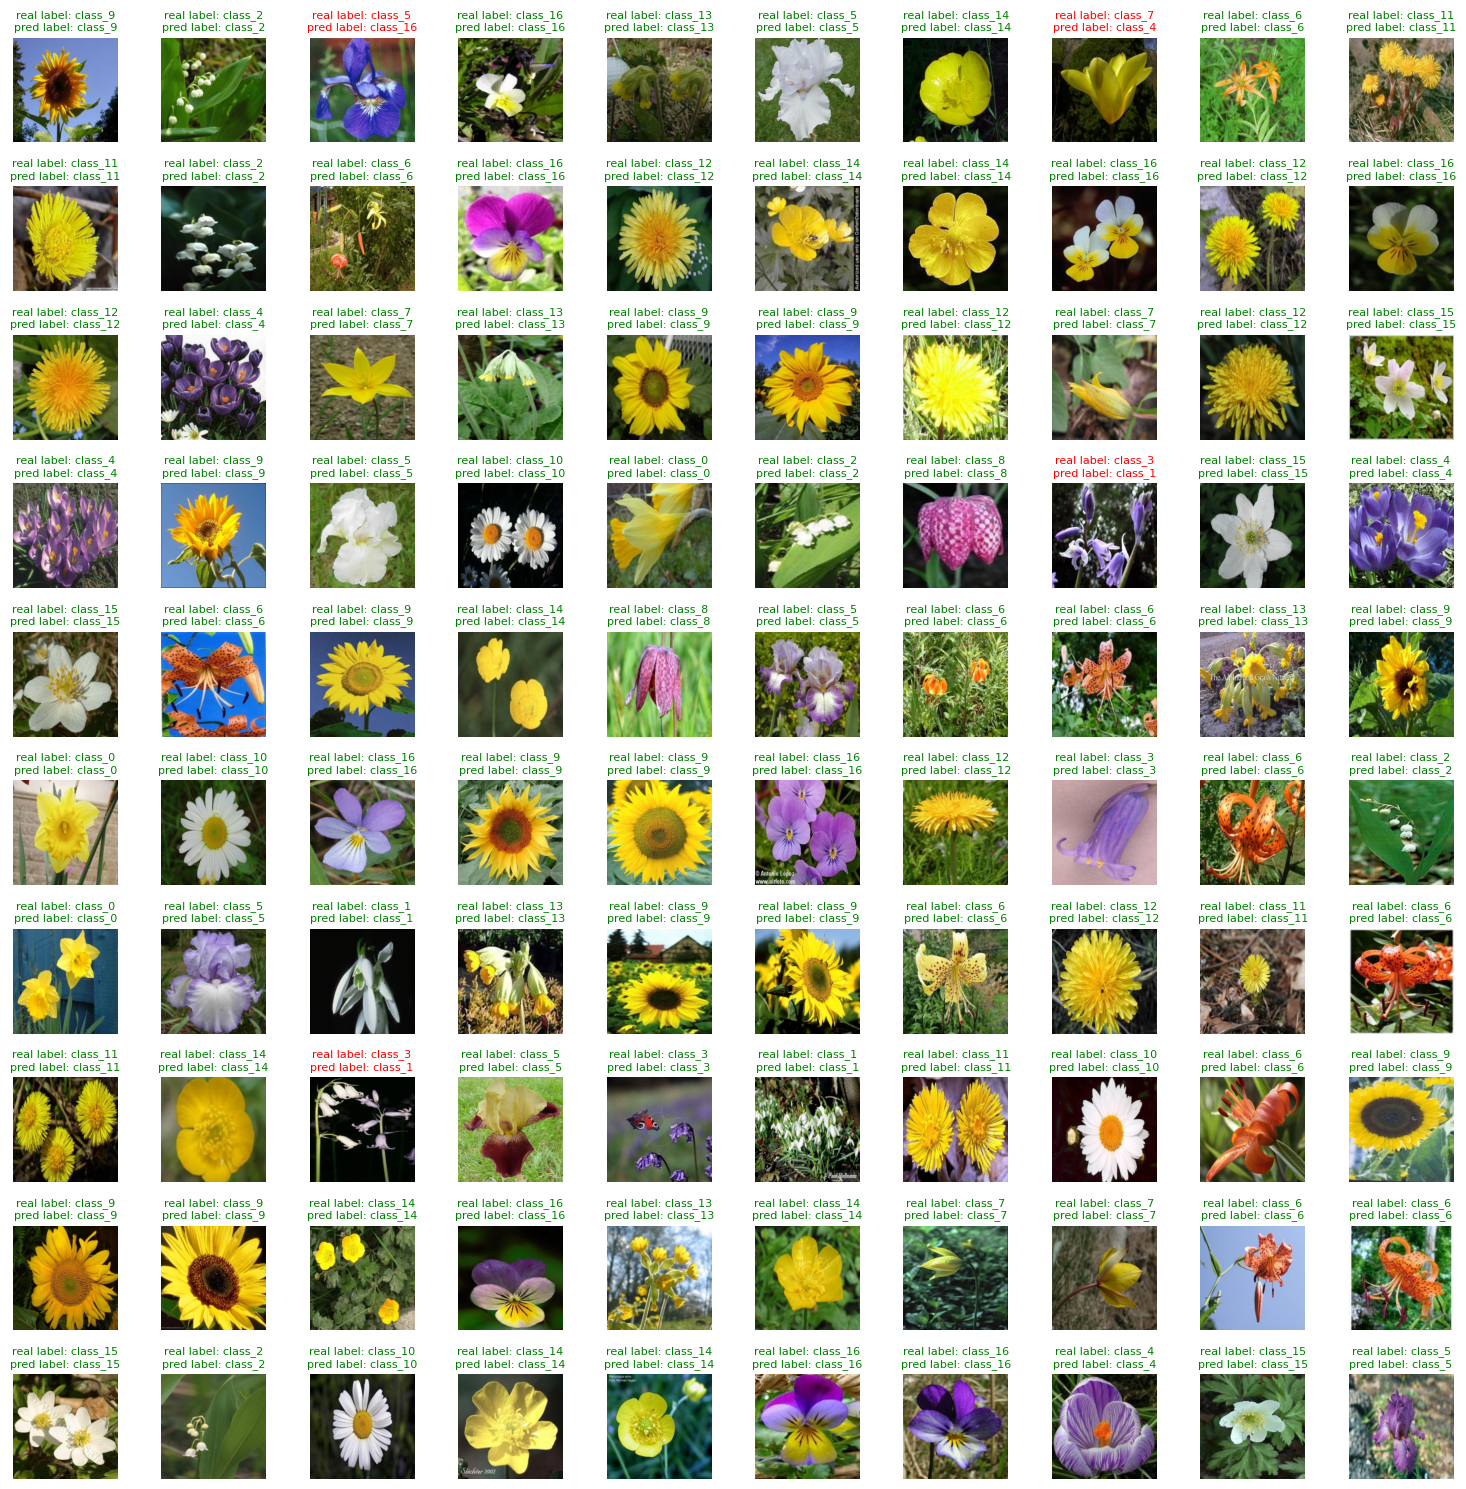

In [273]:
def visualize_predictions(model, loader, class_names, device, num_images=100):
    device = torch.device("mps")
    model.eval()
    images_list = []
    labels_list = []
    preds_list = []

    # all imgs from test_loader
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)   #   кортеж: максимальные значения, их индексы

            images_list.extend(images.cpu())
            labels_list.extend(labels.cpu().numpy())
            preds_list.extend(predicted.cpu().numpy())

    #   take 100 images by random
    indices = random.sample(range(len(images_list)), min(num_images, len(images_list)))
    selected_images = [images_list[i] for i in indices]
    selected_labels = [labels_list[i] for i in indices]
    selected_preds = [preds_list[i] for i in indices]

    #   10x10 net
    _, axes = plt.subplots(10, 10, figsize=(15, 15))
    axes = axes.flatten()

    for i in range(len(selected_images)):
        img = selected_images[i].numpy().transpose((1, 2, 0))  # (C, H, W) → (H, W, C)
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean  #   denoralization
        img = np.clip(img, 0, 1) #  pix values: 0-1

        true_label = class_names[selected_labels[i]]
        pred_label = class_names[selected_preds[i]]
        color = "green" if true_label == pred_label else "red" 

        axes[i].imshow(img)
        axes[i].set_title(f"real label: {true_label}\npred label: {pred_label}", color=color, fontsize=8)
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

class_names = dataset.classes

visualize_predictions(model, test_loader, class_names, device="mps", num_images=100)
